In [68]:
import math
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from scipy.signal import savgol_filter

# CPU-first setup for Colab
device = torch.device('cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Physics Simulation (Allen-Cahn, fixed IC)


In [69]:
def allen_cahn_drift(u, dx, eps: float):
    """
    Compute Allen-Cahn drift with Neumann boundary conditions: u_x(+/-1) = 0
    """
    # Interior points: central difference
    u_xx_interior = (torch.roll(u, -1) - 2 * u + torch.roll(u, 1)) / (dx * dx)

    # Apply Neumann boundary conditions: u_x = 0 at boundaries
    u_xx = u_xx_interior.clone()
    u_xx[..., 0] = (2 * u[..., 1] - 2 * u[..., 0]) / (dx * dx)
    u_xx[..., -1] = (2 * u[..., -2] - 2 * u[..., -1]) / (dx * dx)

    reaction = -(1 / eps**2) * (u**3 - u)
    return u_xx + reaction

def fixed_initial_condition(x: torch.Tensor) -> torch.Tensor:
    """Deterministic initial condition u0(x) = sin(pi * x)."""
    return torch.sin(math.pi * x) #* x**2 * (1 - x)**2

class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        pass

class AllenCahnODE(ODE):
    def __init__(self, dx: float, eps: float):
        super().__init__()
        self.dx = dx
        self.eps = eps

    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return allen_cahn_drift(xt, self.dx, self.eps)

class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor):
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor):
        # assumir ts com shape (1, num_steps+1, 1)
        nts = ts.shape[1]
        for t_idx in range(nts - 1):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor):
        xs = [x.clone()]
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1), desc="Simulating trajectory"):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h)
            xs.append(x.clone())
        return torch.stack(xs, dim=1)

class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor):
        return xt + self.ode.drift_coefficient(xt, t) * h


## 2. Dataset (Normalized, epsilon sweep, fixed IC)


In [70]:
class Sampleable(ABC):
    @property
    @abstractmethod
    def dim(self) -> int:
        pass
    @abstractmethod
    def sample(self, num_samples: int) -> torch.Tensor:
        pass

class AllenCahnDataset(torch.nn.Module, Sampleable):
    def __init__(
        self,
        N: int,
        eps_min: float = 0.02,
        eps_max: float = 1.0,
        num_epsilons: int = 100,
        T: float = 0.02,
        dt: float = 5e-6,
        device=device,
    ):
        super().__init__()
        self.N = N
        self.device = device
        self.T = T  # Store T as an attribute
        self.dt = dt  # Store dt as an attribute

        # spatial grid
        x = torch.linspace(-1, 1, N, device=device)
        self.dx = (x[1] - x[0]).item()
        self.x = x

        # epsilon values
        self.epsilons = torch.logspace(
            math.log10(eps_min),
            math.log10(eps_max),
            steps=num_epsilons,
            device=device,
        )

        # time discretization
        num_steps = int(T / dt)
        ts = torch.linspace(0, T, num_steps + 1, device=device).view(1, -1, 1)

        samples = []
        print(f"Generating Allen-Cahn dataset (eps range: {eps_min} - {eps_max})...")
        for eps in tqdm(self.epsilons):
            u0 = fixed_initial_condition(x).unsqueeze(0)
            ode = AllenCahnODE(self.dx, eps.item())
            simulator = EulerSimulator(ode)
            uT = simulator.simulate(u0, ts)  # shape (1, N)
            samples.append(uT.squeeze(0))

        raw_data = torch.stack(samples, dim=0)

        mean = raw_data.mean()
        std = raw_data.std()
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)
        self.register_buffer("data", (raw_data - mean) / (std + 1e-8))
        print(f"Dataset normalized. Mean: {mean.item():.4f}, Std: {std.item():.4f}")

    @property
    def dim(self) -> int:
        return self.N

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        idx = torch.randint(0, self.data.shape[0], (num_samples,), device=self.device)
        return self.data[idx], self.epsilons[idx].view(-1, 1)

## 3. Optimal Transport Path & 1D CNN Model (no epsilon conditioning)


In [71]:
# --- 1. Initial distribution helper ---
#def sample_x0_fourier_mix(batch_size, x, device, n_modes=8):
    #B = batch_size
    #N = x.shape[0]
    #x = x.to(device)

    #u = torch.zeros(B, N, device=device)
    #xv = x.view(1, -1)

    #for k in range(1, n_modes + 1):
    #    a = torch.randn(B, 1, device=device)
    #    b = torch.randn(B, 1, device=device)
    #    u += a * torch.sin(k * np.pi * xv) + b * torch.cos(k * np.pi * xv)

    # normalize to [-1,1]
    #u = u / (u.abs().max(dim=1, keepdim=True)[0] + 1e-8)

    #return u
'''def sample_x0_fourier_mix(batch_size, x, device, n_modes=8):
    """
    Devolve uma condição inicial gaussiana fixa para todos os elementos do batch.
    Shape de saída: (batch_size, N)
    """
    # garantir que x está no device certo e é 1D
    x = x.to(device)
    if x.ndim > 1:
        x_flat = x.view(-1)
    else:
        x_flat = x

    # parâmetros da gaussiana
    sigma = 0.5  # ajusta se quiseres mais larga/estreita

    # f(x) = exp(-x^2 / (2 sigma^2))  -> shape (N,)
    f = torch.exp(-(x_flat**2) / (2.0 * sigma**2))

    # opcional: normalizar (mas aqui já fica máx ≈ 1)
    # f = f / (f.abs().max() + 1e-8)

    # repetir para todo o batch: (batch_size, N)
    u0 = f.unsqueeze(0).repeat(batch_size, 1)
    return u0'''

def sample_x0_fourier_mix(batch_size, x, device, n_modes=8):
    """
    Gera condições iniciais tipo gaussiana, mas com média e sigma aleatórias
    para cada elemento do batch.

    Saída: (batch_size, N), tal como a versão original.
    """
    x = x.to(device)
    if x.ndim > 1:
        x_flat = x.view(-1)
    else:
        x_flat = x
    # shape (1, N) para broadcast
    x_grid = x_flat.view(1, -1)

    B = batch_size

    # médias ~ Uniform(-0.5, 0.5)  (podes ajustar o intervalo)
    mu = torch.empty(B, 1, device=device).uniform_(-0.5, 0.5)

    # sigma > 0; uso log-uniform entre 0.15 e 0.6, por ex.
    log_sigma_min = math.log(0.15)
    log_sigma_max = math.log(0.6)
    log_sigma = torch.empty(B, 1, device=device).uniform_(log_sigma_min, log_sigma_max)
    sigma = log_sigma.exp()

    # Gaussiana  exp(-(x-mu)^2 / (2 sigma^2)) -> shape (B, N)
    u0 = 0.2 * torch.exp(-((x_grid - mu) ** 2) / (2.0 * sigma ** 2))

    # opcional: dar amplitude aleatória ou normalizar
    # amp = torch.empty(B, 1, device=device).uniform_(0.7, 1.3)
    # u0 = amp * u0

    # opcional: normalizar para [-1, 1] aproximadamente
    # u0 = u0 / (u0.abs().max(dim=1, keepdim=True)[0] + 1e-8)

    return u0

# --- 2. Optimal Transport Path ---
class OptimalTransportPath(torch.nn.Module):
    def __init__(self, p_data: AllenCahnDataset):
        super().__init__()
        self.p_data = p_data

    def sample_batch(self, batch_size: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
            xt: Interpolated state (B, dim)
            t: Time (B, 1)
            ut: Target vector field (B, dim)
            eps: epsilon associated with x1 (B, 1)
        """
        # 1. Get data (x1) and epsilon
        x1, eps = self.p_data.sample(batch_size)

        # 2. Sample Fourier-mix noise (x0)
        x0 = sample_x0_fourier_mix(batch_size, self.p_data.x, x1.device)

        # 3. Sample Time (t)
        t = torch.rand((batch_size, 1), device=x1.device)

        # 4. Interpolate (OT path: straight line)
        xt = (1 - t) * x0 + t * x1

        # 5. Target Vector Field (u_t = x1 - x0)
        ut = x1 - x0

        return xt, t, ut, eps

# --- 3. 1D CNN Vector Field (Spatial Bias) ---
class Conv1DVectorField(torch.nn.Module):
    def __init__(self, dim: int):
        super().__init__()

        # We concatenate x and t as channels -> 2 input channels
        self.down1 = torch.nn.Conv1d(3, 64, kernel_size=7, padding=3)
        self.down2 = torch.nn.Conv1d(64, 128, kernel_size=7, padding=3)
        self.mid   = torch.nn.Conv1d(128, 128, kernel_size=7, padding=3)
        self.up1   = torch.nn.Conv1d(128, 64, kernel_size=7, padding=3)
        self.out   = torch.nn.Conv1d(64, 1, kernel_size=7, padding=3)

        self.act = torch.nn.SiLU()

    '''def forward(self, x, t):
        # x: (B, N)
        # t: (B, 1)

        B, N = x.shape

        x_map = x.unsqueeze(1)  # (B, 1, N)
        t_map = t.unsqueeze(-1).expand(B, 1, N)  # (B, 1, N)

        h = torch.cat([x_map, t_map], dim=1)  # (B, 2, N)'''
    def forward(self, x, t, eps):
        # x:   (B, N)
        # t:   (B, 1)
        # eps: (B, 1)

        B, N = x.shape

        x_map   = x.unsqueeze(1)                          # (B, 1, N)
        t_map   = t.unsqueeze(-1).expand(B, 1, N)         # (B, 1, N)
        eps_map = eps.unsqueeze(-1).expand(B, 1, N)       # (B, 1, N)

        # 3 canais: x, t, eps
        h = torch.cat([x_map, t_map, eps_map], dim=1)     # (B, 3, N)


        h1 = self.act(self.down1(h))   # (B, 64, N)
        h2 = self.act(self.down2(h1))  # (B, 128, N)
        h_mid = self.act(self.mid(h2)) # (B, 128, N)

        h3 = self.act(self.up1(h_mid)) # (B, 64, N)
        h3 = h3 + h1  # Skip connection

        out = self.out(h3)  # (B, 1, N)
        return out.squeeze(1)


In [72]:
def allen_cahn_residual(model, x, t, eps):
    t.requires_grad_(True)
    x.requires_grad_(True)
    eps = eps.clone().detach()
    u = model(x, t, eps)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    f = u**3 - u
    r = u_t - eps**2 * u_xx + f
    return r

def compute_initial_condition_loss(model, u0_func, N_samples, eps_val, device):
    """
    Compute initial condition loss: u(x, 0) = u0(x)

    Args:
        model: Flow matching model
        u0_func: Function that computes u0(x)
        N_samples: Number of samples
        eps_val: Epsilon value
        device: torch device

    Returns:
        loss_IC: Initial condition loss
    """
    N_spatial = 200
    x = torch.linspace(-1, 1, N_spatial, device=device)

    # Sample random initial states
    X_IC = torch.randn(N_samples, N_spatial, device=device)

    # Time = 0 for initial condition
    t_IC = torch.zeros(N_samples, 1, device=device)
    eps_tensor = torch.full((N_samples, 1), eps_val, device=device)

    # Predict at t=0
    u_pred = model(X_IC, t_IC, eps_tensor)

    # Compute true initial condition
    u_true = u0_func(x).unsqueeze(0).expand(N_samples, -1)

    loss_IC = torch.mean((u_pred - u_true)**2)

    return loss_IC

'''def compute_boundary_loss(model, N_samples, eps_val, device):
    """
    Compute Neumann boundary condition loss: u_x(±1, t) = 0

    Args:
        model: Flow matching model
        N_samples: Number of samples
        eps_val: Epsilon value
        device: torch device

    Returns:
        loss_BC: Boundary condition loss
    """
    # Sample random times
    t_samples = torch.rand(N_samples, 1, device=device)
    eps_tensor = torch.full((N_samples, 1), eps_val, device=device)

    # Create spatial fields with emphasis on boundaries
    # We'll create fields that are mostly zeros except near boundaries
    N_spatial = 200  # Match your flow matching setup
    x = torch.linspace(-1, 1, N_spatial, device=device)

    # Create random fields
    X_BC = torch.randn(N_samples, N_spatial, device=device).requires_grad_(True)

    # Predict
    u = model(X_BC, t_samples, eps_tensor)

    # Compute spatial derivative at boundaries
    dx = x[1] - x[0]

    # Left boundary (x=-1)
    u_x_left = (u[:, 1] - u[:, 0]) / dx

    # Right boundary (x=1)
    u_x_right = (u[:, -1] - u[:, -2]) / dx

    loss_BC = torch.mean(u_x_left**2 + u_x_right**2)

    return loss_BC'''

def compute_boundary_loss(model, t, eps, device, N_spatial=200):
    """
    Neumann BC: u_x(±1, t) = 0
    Aplica a BC para um batch de tempos t e eps (mesmo shape do treino).

    Args:
        model : rede u_theta(x_field, t, eps)
        t     : (B, 1)
        eps   : (B, 1)
        device: torch.device
        N_spatial : número de pontos em x (igual ao do flow)
    """
    B = t.shape[0]
    x = torch.linspace(-1.0, 1.0, N_spatial, device=device)
    dx = x[1] - x[0]

    # campos "falsos" só para impor BC: ruído em x
    X_BC = torch.randn(B, N_spatial, device=device)

    # u(x, t, eps) que queremos que respeite BC
    u = model(X_BC, t, eps)  # (B, N_spatial)

    # derivada espacial nas fronteiras (diferença finita 1ª ordem)
    u_x_left  = (u[:, 1]  - u[:, 0])   / dx  # x = -1
    u_x_right = (u[:, -1] - u[:, -2]) / dx   # x =  1

    loss_BC = torch.mean(u_x_left**2 + u_x_right**2)
    return loss_BC



## 4. Training Loop


In [78]:
class Trainer(ABC):
    def __init__(self, model: torch.nn.Module):
        super().__init__()
        self.model = model

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def get_optimizer(self, lr: float):
        return torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, num_epochs: int, device: torch.device, lr: float = 1e-3, batch_size: int = 128):
        self.model.to(device)
        opt = self.get_optimizer(lr)
        self.model.train()

        loss_history = []

        pbar = tqdm(range(num_epochs))
        for epoch in pbar:
            opt.zero_grad()
            loss = self.get_train_loss(batch_size=batch_size)
            loss.backward()
            opt.step()

            loss_history.append(loss.item())
            pbar.set_description(f"Epoch {epoch} | Loss={loss.item():.4f}")

        self.model.eval()
        return loss_history

class OTFlowMatchingTrainer(Trainer):
    def __init__(self, path: OptimalTransportPath, model: torch.nn.Module):
        super().__init__(model)
        self.path = path

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        xt, t, u_star, eps = self.path.sample_batch(batch_size)

        u_theta = self.model(xt, t, eps)
        loss_fm = ((u_theta - u_star) ** 2).mean()

        # --- aplicar PDE apenas na "última parte do caminho" ---
        t_thresh = 0.9          # por ex. último 10% do caminho
        mask = (t.squeeze(-1) > t_thresh)   # (B,)

        if mask.any():
            r = allen_cahn_residual(self.model, xt[mask], t[mask], eps[mask])
            loss_pde = (r**2).mean()
        else:
            loss_pde = torch.zeros((), device=device)

        # ----- Boundary loss também só para t grandes -----
        if mask.any():
            loss_bc = compute_boundary_loss(
                self.model,
                t[mask],
                eps[mask],
                device=device)
     # se tiveres p_data.N guardado como dim

        else:
            loss_bc = torch.zeros((), device=device)

        loss = loss_fm + 0.1 * loss_pde + 0.1 * loss_bc
        return loss


Generating Allen-Cahn dataset (eps range: 0.02 - 1.0)...


100%|██████████| 100/100 [00:44<00:00,  2.23it/s]


Dataset normalized. Mean: 0.0000, Std: 0.8221


Epoch 999 | Loss=0.2439: 100%|██████████| 1000/1000 [27:21<00:00,  1.64s/it]


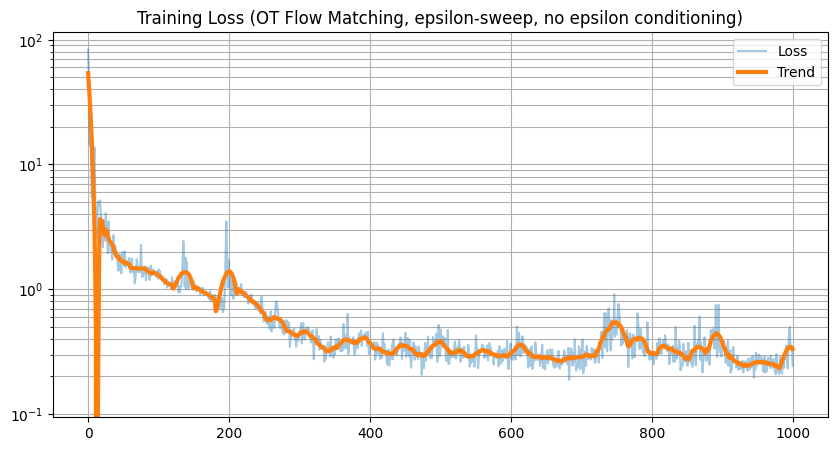

In [79]:
# ---- p_data: Allen-Cahn final fields in R^N ----
p_data = AllenCahnDataset(
    N=200,
    eps_min=0.02,
    eps_max=1.0,
    num_epsilons=100,
    T=0.02,
    dt=1e-5,
    device=device,
).to(device)

# ---- OT Path ----
path = OptimalTransportPath(p_data).to(device)

# ---- 1D CNN Vector Field ----
flow_model = Conv1DVectorField(dim=p_data.dim).to(device)

# ---- Trainer ----
trainer = OTFlowMatchingTrainer(path, flow_model)

# ---- Train ----
losses = trainer.train(
    num_epochs=1000,
    device=device,
    lr=1e-3,
    batch_size=128,
)

# ---- Plot Loss ----
plt.figure(figsize=(10, 5))
plt.plot(losses, label="Loss", alpha=0.4)
plt.plot(savgol_filter(losses, 31, 3), label="Trend", linewidth=3)
plt.title("Training Loss (OT Flow Matching, epsilon-sweep, no epsilon conditioning)")
plt.yscale('log')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()


## 5. Sampling & Visualization (epsilon chosen at eval)


Simulating trajectory: 100%|██████████| 99/99 [00:00<00:00, 287.00it/s]


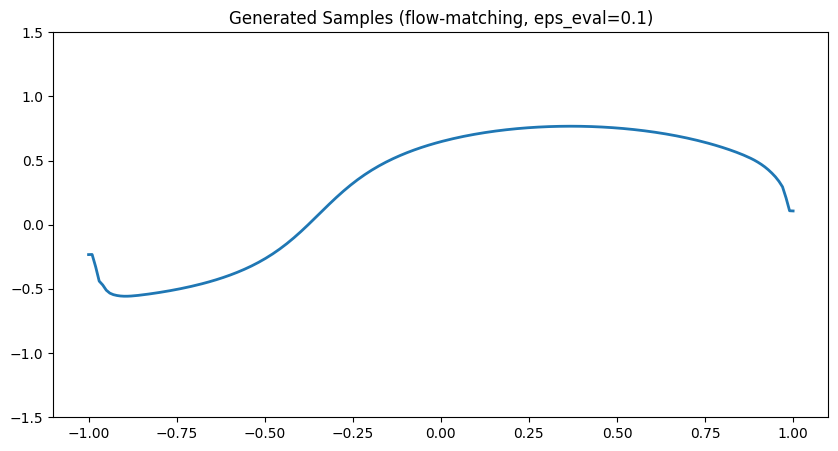

In [80]:
class LearnedVectorFieldODE(ODE):
    def __init__(self, net, eps_eval: float):
        self.net = net
        self.eps_eval = eps_eval

    def drift_coefficient(self, x, t):
        B, N = x.shape
        eps = torch.full((B, 1), self.eps_eval, device=x.device)
        return self.net(x, t, eps)

# ==========================================
# Generate Samples from Learned Flow (choose eps_eval)
# ==========================================
eps_eval = 0.1  # pick an epsilon to simulate physics
num_samples = 1
ts = torch.linspace(0.0, 1.0, 100, device=device).view(1, -1, 1).expand(num_samples, -1, 1)
x_grid = p_data.x.cpu()

ode = LearnedVectorFieldODE(flow_model, eps_eval)
simulator = EulerSimulator(ode)

x0 = sample_x0_fourier_mix(num_samples, p_data.x, device)
xts = simulator.simulate_with_trajectory(x0, ts)

# Un-normalize with dataset stats
final_samples = xts[:, -1, :].detach().cpu() * p_data.std.cpu() + p_data.mean.cpu()

plt.figure(figsize=(10, 5))
plt.title(f"Generated Samples (flow-matching, eps_eval={eps_eval})")
plt.ylim(-1.5, 1.5)
for j in range(num_samples):
    plt.plot(x_grid, final_samples[j], linewidth=2)
plt.show()


Simulating trajectory: 100%|██████████| 99/99 [00:00<00:00, 99.45it/s]


Generating Ground Truth samples for comparison...


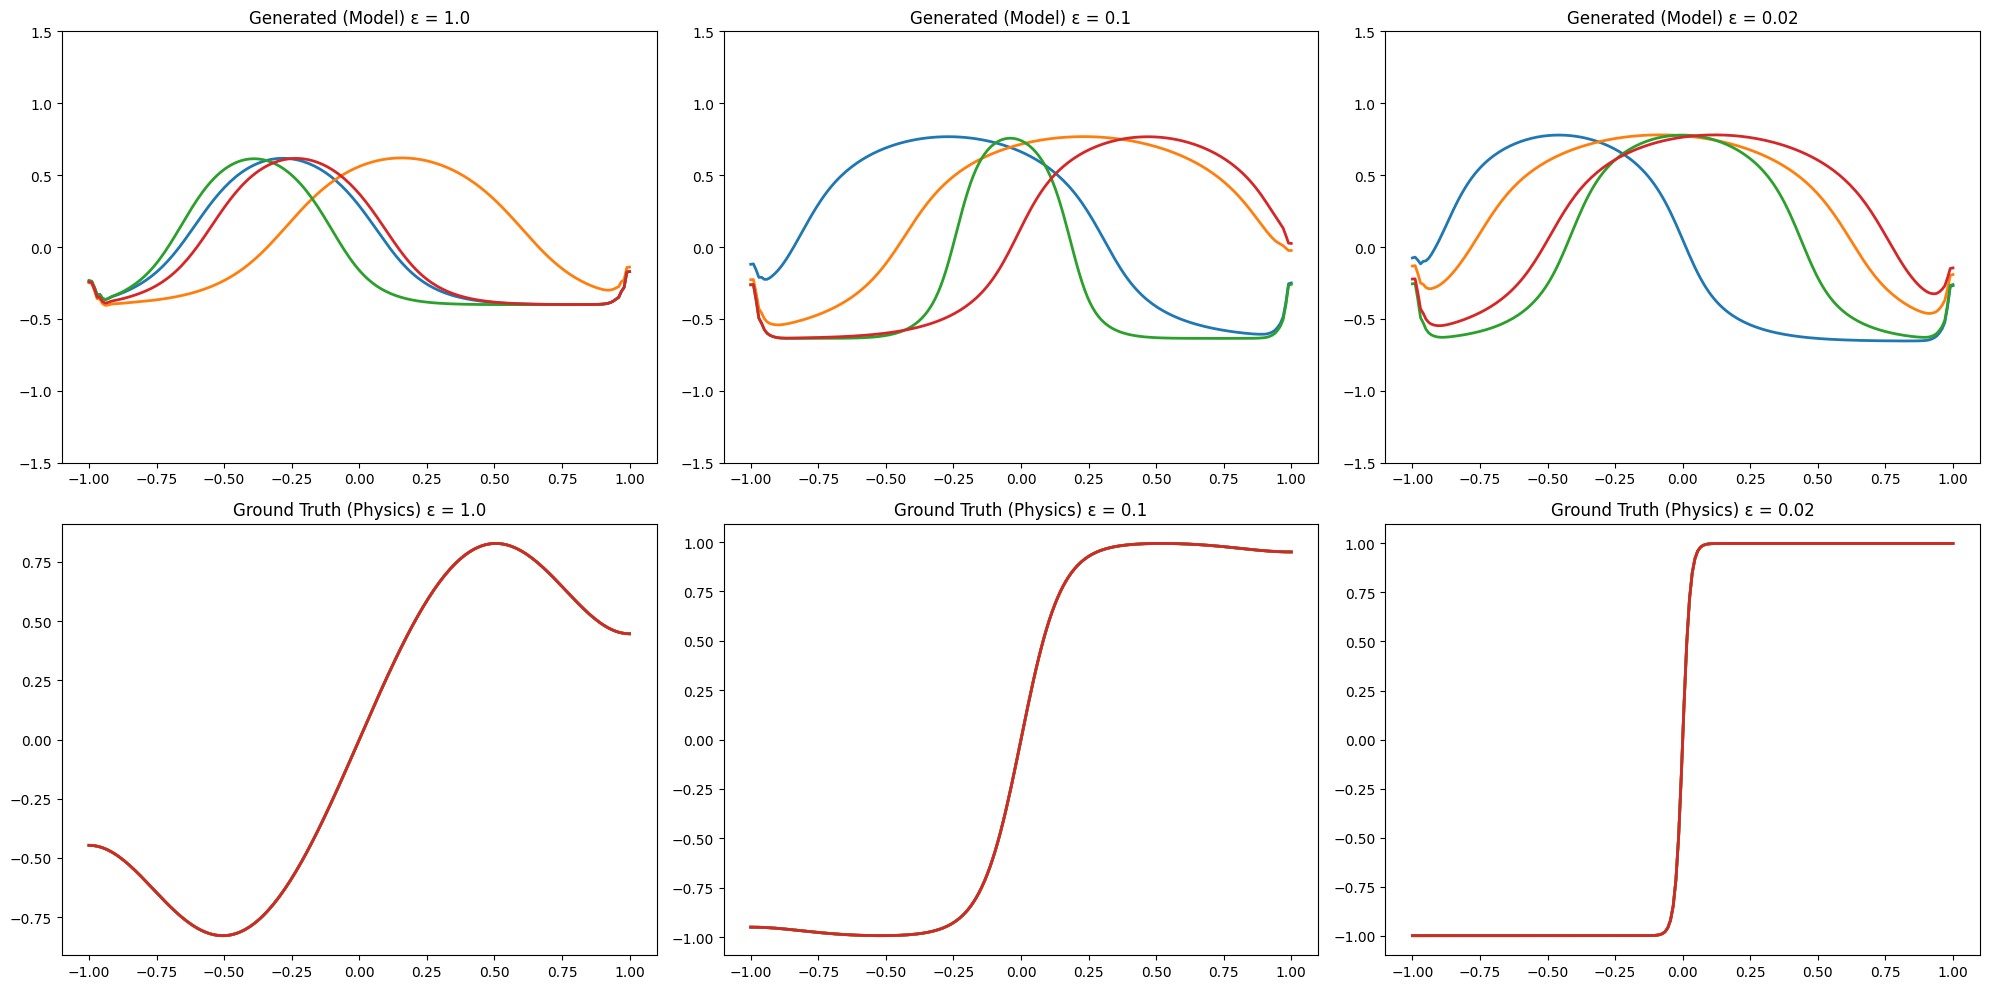

In [83]:
# ==========================================
# Compare Generated Samples vs Ground Truth
# ==========================================
eps_to_test = [1.0, 0.1, 0.02]
num_samples = 4
ts = torch.linspace(0.0, 1.0, 100, device=device).view(1, -1, 1).expand(num_samples, -1, 1)
x_grid = p_data.x.cpu()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Row 1: Generated Samples
for i, eps_val in enumerate(eps_to_test):
    # 1. Setup ODE with specific epsilon
    ode = LearnedVectorFieldODE(flow_model, eps_val)
    simulator = EulerSimulator(ode)

    # 2. Sample Noise
    x0 = sample_x0_fourier_mix(num_samples, p_data.x, device)

    # 3. Simulate
    xts = simulator.simulate_with_trajectory(x0, ts)

    # 4. Plot Final States (Un-normalized)
    final_samples = xts[:, -1, :].detach().cpu() * p_data.std.cpu() + p_data.mean.cpu()

    axes[0, i].set_title(f"Generated (Model) ε = {eps_val}")
    axes[0, i].set_ylim(-1.5, 1.5)
    for j in range(num_samples):
        axes[0, i].plot(x_grid, final_samples[j], linewidth=2)

# Row 2: Ground Truth Samples
print("Generating Ground Truth samples for comparison...")
for i, eps_val in enumerate(eps_to_test):
    axes[1, i].set_title(f"Ground Truth (Physics) ε = {eps_val}")
    #axes[1, i].set_ylim(-1.5, 1.5)

    # Generate fresh ground truth samples for this specific epsilon
    for j in range(num_samples):
        # Use the same physics generation code as the dataset
        u0 = fixed_initial_condition(p_data.x).unsqueeze(0)
        ode = AllenCahnODE(p_data.dx, eps_val)
        simulator = EulerSimulator(ode)

        # Simulate physics
        # Note: We use the same T and dt as training
        ts_physics = torch.linspace(0, p_data.T, int(p_data.T / p_data.dt) + 1, device=device).view(1, -1, 1)

        uT = simulator.simulate(u0, ts_physics)
        #print(uT)

        axes[1, i].plot(x_grid, uT.squeeze().cpu(), linewidth=2)

plt.tight_layout()
plt.show()

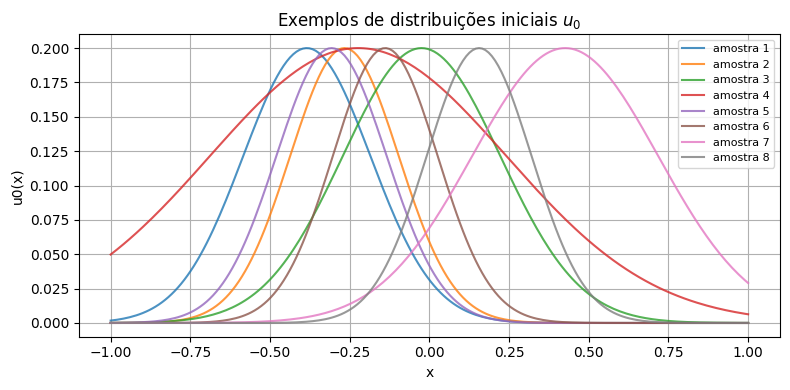

In [82]:
x = p_data.x              # shape (N,)
device = x.device

batch_size = 8            # quantas distribuições iniciais queres ver
u0_batch = sample_x0_fourier_mix(batch_size, x, device)  # (B, N)

# passar para CPU + numpy para plot
x_np = x.detach().cpu().numpy()
u0_np = u0_batch.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
for i in range(batch_size):
    plt.plot(x_np, u0_np[i], label=f"amostra {i+1}", alpha=0.8)

plt.xlabel("x")
plt.ylabel("u0(x)")
plt.title("Exemplos de distribuições iniciais $u_0$")
plt.grid(True)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()